#(Sentiment Analysis) Text Classification with RNN.


In [159]:
import os
import zipfile
import pandas as pd
import numpy as np
import re
import nltk
!pip install gensim
import gensim.downloader as api
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
!pip install contractions
import contractions
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
!pip install gradio
import gradio as gr

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding:

###  Load the dataset:

• Use Pandas to load the raw tweet data.

In [160]:
from google.colab import drive
import zipfile

drive.mount('/content/drive', force_remount=True)
zip_path = '/content/drive/MyDrive/AI and ML/spamVsHams_sms.zip'

if os.path.exists(zip_path):
    print(f"File found. Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('dataset/')
        print("Extraction complete.")
    except zipfile.BadZipFile:
        print("Error: The file exists but is not a valid zip file. It may be corrupted or partially uploaded.")
else:
    print("Error: The file path does not exist. Please check the path in your Google Drive.")

Mounted at /content/drive
File found. Size: 0.20 MB
Extraction complete.


In [161]:
dataset_path = '/content/dataset/9.Spam vs Ham Sms Dataset/spamvsham.csv'
df = pd.read_csv(dataset_path, encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [162]:
# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'text']

# Display first rows
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [163]:
df.isnull().any()

,0
label,False
text,False


### Clean the text:

•Perform the following preprocessing steps on the text:

– Lowercase all text to ensure uniformity.

– Remove URLs, mentions (@user), hashtags (#), numbers, and special characters.

– Handle contractions (e.g., "don’t" → "do not").

– Remove stopwords and lemmatize words to reduce words to their base form.

In [164]:
def expand_contractions(text):
    return contractions.fix(text)

In [165]:
#Convert the input to small/lower order
def lower_order(text):
  return text.lower()

In [166]:
#Remove urls
def remove_urls(text):
  """
  This function will try to remove URL present in out dataset and replace it with space using regex library.
  Input Args:
  text: strings of text that may contain URLs.
  Output Args:
  text: URLs replaces with text
  """
  url_pattern = re.compile(r'https?://\S+|www\.\S+')
  return url_pattern.sub(r'', text)

In [167]:
#Remove mentions
def remove_mentions(text):
  return re.sub(r'@\w+', '', text)

In [168]:
# remove special character like emojis
def remove_special_character(string):
  """
  This function will replace the emoji in string with whitespace
  """
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', string)


In [169]:
# Remove mentions (words starting with @)
def remove_unwanted_characters(document):
    """
    This function will remove all the unwanted characters from the input dataset.
    Input Args:
    documet: A text data to be cleaned.
    Return:
    A cleaned document.
    """
    document = re.sub("@[A-Za-z0-9_]+", " ", document)
    document = re.sub("#[A-Za-z0-9_]+", " ", document)  # ← " " not ""
    document = re.sub("[^A-Za-z ]", " ", document)       # ← " " not ""
    document = remove_special_character(document)
    document = re.sub(r'\s+', ' ', document)             # collapse multiple spaces
    return document.strip()

In [170]:
def word_tokenizer(text):
  return word_tokenize(text)

In [171]:
stop_words = set(stopwords.words('english'))
custom_stopwords = ['@', 'RT']
stop_words.update(custom_stopwords)

def remove_stopwords(text_tokens):
  """
  This function removes all the stopwords present in out text tokens.
  Input Args:
  text_tokens: tokenize input of our datasets.
  Returns:
  result_tokens: list of token without stopword.
  """

  result_tokens = []
  for token in text_tokens:
    if token not in stop_words:
       result_tokens.append(token)
  return result_tokens

In [172]:
def stemming(text):
  """
  This function performs stemming operations.
  Input Args:
  token_text: list of tokenize text.
  Returns:
  stemm_tokes: list of stemmed tokens.
  """
  porter = PorterStemmer()
  stemm_tokens = []
  for word in text:
    stemm_tokens.append(porter.stem(word))
  return stemm_tokens

In [173]:
def lemmatization(token_text):
  """
  This function performs the lemmatization operations as explained above.
  Input Args:
  token_text: list of tokens.
  Returns:
  lemmatized_tokens: list of lemmatized tokens.
  """
  lemma_tokens = []
  wordnet = WordNetLemmatizer()
  lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]

  return lemmatized_tokens

In [174]:
def text_cleaning_pipeline(dataset, rule = "lemmatize"):
  """
  This function takes a dataset (text) and applies a series of text cleaning steps.
  It converts text to lowercase, removes URLs, emojis, and other unwanted characters.
  It then tokenizes the text, removes stopwords, and finally applies either lemmatization or stemming.

  Args:
    dataset (str): The input text string to be cleaned.
    rule (str, optional): The rule to apply for word normalization. Can be 'lemmatize' or 'stem'. Defaults to 'lemmatize'.

  Returns:
    str: The cleaned and processed text string.
  """
  data = expand_contractions(dataset)

  # Convert the input to small/lower order.
  data = lower_order(dataset)

  # Remove URLs
  data = remove_urls(data)

  # Remove mentions
  data = remove_mentions(data)

  # Remove emojis
  data = remove_special_character(data)

  # Remove all other unwanted characters (punctuation and numbers)
  data = remove_unwanted_characters(data)

  # Create tokens.
  tokens = word_tokenizer(data)

 # Stopword removal
  stop_words = set(stopwords.words('english'))
  custom_stopwords = ['@', 'RT']
  stop_words.update(custom_stopwords)

  tokens = [word for word in tokens if word not in stop_words]

  if rule == "lemmatize":
      tokens = lemmatization(tokens)
  elif rule == "stem":
      tokens = stemming(tokens)
  else:
      raise ValueError("Pick between 'lemmatize' or 'stem'")

  return " ".join(tokens)

In [175]:
df['clean_text'] = df['text'].apply(text_cleaning_pipeline)

# View cleaned data
df[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf live around though


### Visualize the cleaned data:

• Use tools like a word cloud or display the most frequent words to explore
the cleaned data.

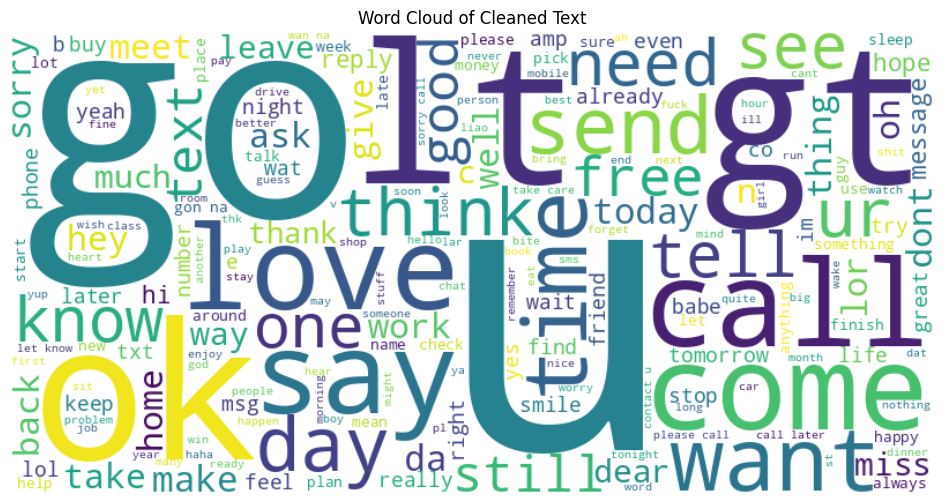

In [176]:
# Combine all cleaned text into one string
all_words = " ".join(df['clean_text'])

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

# Display word cloud
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Text")
plt.show()


### Tokenization and Padding:

• Convert the cleaned text data into sequences and ensure uniform sequence lengths by applying padding:

– Split the dataset into 80% training and 20% testing using train test split.

– Use Keras Tokenizer to convert the text into sequences of integers.

– Apply padding to ensure all sequences have the same length. Utilize percentile-based padding to
avoid excessively long sequences.

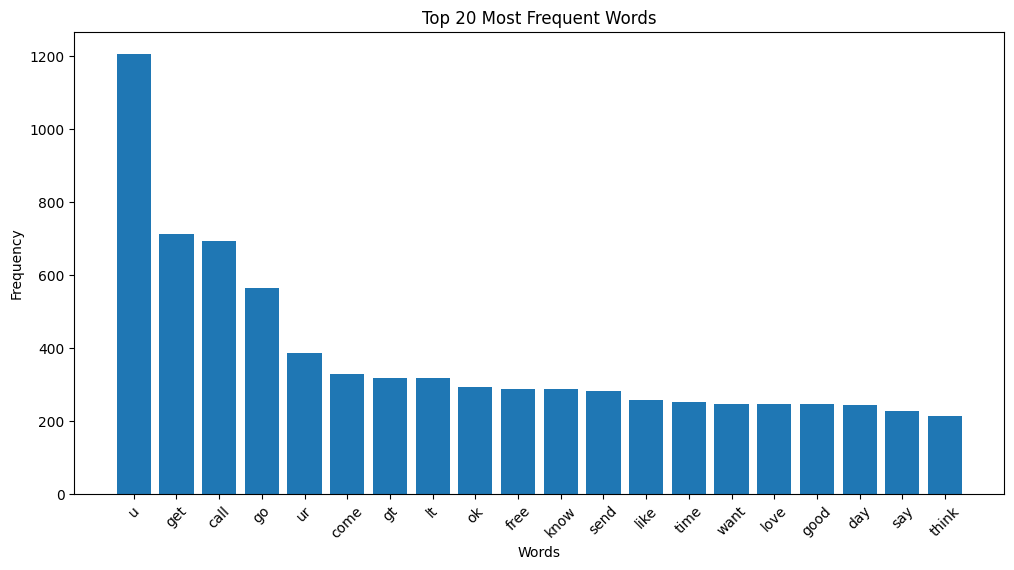

In [177]:
# Tokenize all words
tokens = all_words.split()

# Count word frequency
word_freq = Counter(tokens)

# Get top 20 most common words
top_words = word_freq.most_common(20)

# Separate words and counts
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

# Plot
plt.figure(figsize=(12,6))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [178]:
# Train-Test Split
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 4457
Testing samples : 1115


In [179]:
# Define vocabulary size
VOCAB_SIZE = 10000

# Create tokenizer
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

# Fit tokenizer on training data
tokenizer.fit_on_texts(X_train)

# Convert text into integer sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences  = tokenizer.texts_to_sequences(X_test)

# Example
print("\nOriginal Text:")
print(X_train.iloc[0])

print("\nSequence:")
print(X_train_sequences[0])


Original Text:
go nothing great bye

Sequence:
[5, 242, 66, 992]


In [180]:
# Calculate sequence lengths
sequence_lengths = [len(seq) for seq in X_train_sequences]

# Use 95th percentile to avoid very long sequences
max_length = int(np.percentile(sequence_lengths, 95))

print("\nChosen Max Length (95th percentile):", max_length)

# Apply padding
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Check shape
print("\nTraining padded shape:", X_train_padded.shape)
print("Testing padded shape :", X_test_padded.shape)


Chosen Max Length (95th percentile): 20

Training padded shape: (4457, 20)
Testing padded shape : (1115, 20)


In [181]:
# Convert ham/spam to numbers
y_train = y_train.map({'ham':0, 'spam':1})
y_test  = y_test.map({'ham':0, 'spam':1})

print("\nEncoded Labels Example:")
print(y_train.head())


Encoded Labels Example:
184     0
2171    0
5422    0
4113    0
4588    0
Name: label, dtype: int64


## 4.5.2 Model Building and Training:

### 1. Simple RNN with a trainable Embedding layer.

In [182]:
embedding_dim = 100

# Model 1: RNN with a trainable Embedding layer

# Build model
rnn_model = Sequential()

# Embedding Layer
rnn_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=embedding_dim
    )
)

# SimpleRNN Layer
rnn_model.add(SimpleRNN(64))

# Dropout
rnn_model.add(Dropout(0.5))

# Output Layer
rnn_model.add(Dense(1, activation='sigmoid'))

# Build the model manually
rnn_model.build(input_shape=(None, max_length))

# Compile
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Summary
rnn_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,625 (3.86 MB)

 Trainable params: 1,010,625 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

### 2. LSTM with a trainable Embedding layer.

In [183]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_length,)))

lstm_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=embedding_dim
    )
)

lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,305 (3.98 MB)

 Trainable params: 1,042,305 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

### 3. LSTM with pretrained GloVe embeddings

In [184]:
# Load 50-dimensional GloVe vectors
embedding_model = api.load('glove-twitter-200')

print("Embedding model loaded successfully!")

# Confirm it loaded correctly
print("\nLoaded:", embedding_model.__class__.__name__)
print("Vector size:", embedding_model.vector_size)
print("'ur' in vocab:", "ur" in embedding_model.key_to_index)
print("'lol' in vocab:", "lol" in embedding_model.key_to_index)

Embedding model loaded successfully!

Loaded: KeyedVectors
Vector size: 200
'ur' in vocab: True
'lol' in vocab: True


In [185]:
embedding_dim = 200
embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))

hits, misses = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue

    # Fix 1: try exact match first
    if word in embedding_model.key_to_index:
        embedding_matrix[idx] = embedding_model.vectors[embedding_model.key_to_index[word]]
        hits += 1

    # Fix 2: try singular/plural fallback
    elif word + 's' in embedding_model.key_to_index:
        embedding_matrix[idx] = embedding_model.vectors[embedding_model.key_to_index[word + 's']]
        hits += 1

    # Fix 3: try stripping trailing 's' (plurals)
    elif word.endswith('s') and word[:-1] in embedding_model.key_to_index:
        embedding_matrix[idx] = embedding_model.vectors[embedding_model.key_to_index[word[:-1]]]
        hits += 1

    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f'Embedding matrix shape : {embedding_matrix.shape}')
print(f'Word hits              : {hits}')
print(f'Word misses            : {misses}')
print(f'Coverage               : {coverage:.1f}%')

Embedding matrix shape : (10000, 200)
Word hits              : 5096
Word misses            : 728
Coverage               : 87.5%


In [186]:
# Run this to see your actual miss words
miss_words = []
hit_words = []

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word not in embedding_model.key_to_index:
        miss_words.append((word, idx))
    else:
        hit_words.append(word)

print(f"Hits  : {len(hit_words)}")
print(f"Misses: {len(miss_words)}")
print("\nFirst 50 missed words:")
for word, idx in sorted(miss_words, key=lambda x: x[1])[:50]:
    print(f"  idx {idx:5d} | '{word}'")

Hits  : 5069
Misses: 755

First 50 missed words:
  idx     1 | '<OOV>'
  idx   224 | 'pobox'
  idx   448 | 'optout'
  idx   501 | 'chikku'
  idx   527 | 'savamob'
  idx   585 | 'mobileupd'
  idx   714 | 'bslvyl'
  idx   760 | 'custcare'
  idx   768 | 'freemsg'
  idx   770 | 'rakhesh'
  idx  1002 | 'callertune'
  idx  1017 | 'tscs'
  idx  1019 | 'fullonsms'
  idx  1087 | 'shuhui'
  idx  1092 | 'toclaim'
  idx  1149 | 'aathi'
  idx  1233 | 'stoptxt'
  idx  1239 | 'yijue'
  idx  1277 | 'sipix'
  idx  1367 | 'netcollex'
  idx  1387 | 'geeee'
  idx  1394 | 'bcums'
  idx  1396 | 'kettoda'
  idx  1409 | 'jamster'
  idx  1418 | 'yogasana'
  idx  1448 | 'prabha'
  idx  1462 | 'freefone'
  idx  1469 | 'nimya'
  idx  1491 | 'ansr'
  idx  1509 | 'unredeemed'
  idx  1547 | 'thangam'
  idx  1565 | 'linerental'
  idx  1583 | 'csbcm'
  idx  1584 | 'callcost'
  idx  1591 | 'txtauction'
  idx  1596 | 'skilgme'
  idx  1597 | 'winawk'
  idx  1598 | 'perwksub'
  idx  1599 | 'videophones'
  idx  1603 | 'nol

In [187]:
pretrained_lstm_model = Sequential()

pretrained_lstm_model.add(Input(shape=(max_length,)))

# Pretrained Embedding
pretrained_lstm_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)

# LSTM
pretrained_lstm_model.add(LSTM(64))

# Dropout
pretrained_lstm_model.add(Dropout(0.5))

# Output
pretrained_lstm_model.add(Dense(1, activation='sigmoid'))

# Compile
pretrained_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

pretrained_lstm_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 20, 200)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,067,905 (7.89 MB)

 Trainable params: 67,905 (265.25 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

## 4.5.3 Model Training and Evaluation:

###  • Compile models with following configurations:
– Appropriate Loss Function.

– Appropriate optimizer.

– Appropriate Metrics.

### • Train the Models for desired number of epochs using callbacks and early stopping.

In [188]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [189]:
history_rnn = rnn_model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9450 - loss: 0.1690 - val_accuracy: 0.9765 - val_loss: 0.0773
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9874 - loss: 0.0554 - val_accuracy: 0.9765 - val_loss: 0.0813
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9927 - loss: 0.0342 - val_accuracy: 0.9765 - val_loss: 0.0860
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9947 - loss: 0.0225 - val_accuracy: 0.9720 - val_loss: 0.1181


In [190]:
history_lstm = lstm_model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9279 - loss: 0.2024 - val_accuracy: 0.9742 - val_loss: 0.0750
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9879 - loss: 0.0492 - val_accuracy: 0.9765 - val_loss: 0.0831
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9952 - loss: 0.0187 - val_accuracy: 0.9787 - val_loss: 0.1010
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9989 - loss: 0.0063 - val_accuracy: 0.9787 - val_loss: 0.0973


In [191]:
history_pretrained = pretrained_lstm_model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9240 - loss: 0.2126 - val_accuracy: 0.9585 - val_loss: 0.1059
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9792 - loss: 0.0685 - val_accuracy: 0.9765 - val_loss: 0.0712
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9877 - loss: 0.0446 - val_accuracy: 0.9697 - val_loss: 0.0745
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9905 - loss: 0.0346 - val_accuracy: 0.9787 - val_loss: 0.0683
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9947 - loss: 0.0224 - val_accuracy: 0.9765 - val_loss: 0.0725
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9950 - loss: 0.0180 - val_accuracy: 0.9821 - val_loss: 0.0643
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9944 - loss: 0.0147 - val_accuracy: 0.9798 - val_loss: 0.0706
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9978 - loss: 0.0101 - val_accuracy: 0

### • Visualization:
– Plot the Training vs. Validation loss and accuracy over epochs.

– Compare the performance of the Model 1 vs. Model 2 vs. Model 3

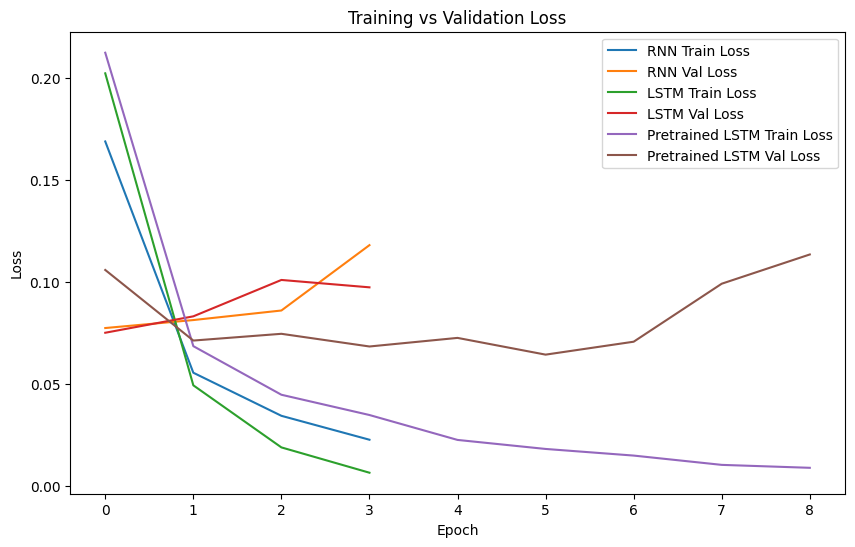

In [195]:
plt.figure(figsize=(10,6))

# RNN
plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Val Loss')

# LSTM
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')

# Pretrained LSTM
plt.plot(history_pretrained.history['loss'], label='Pretrained LSTM Train Loss')
plt.plot(history_pretrained.history['val_loss'], label='Pretrained LSTM Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

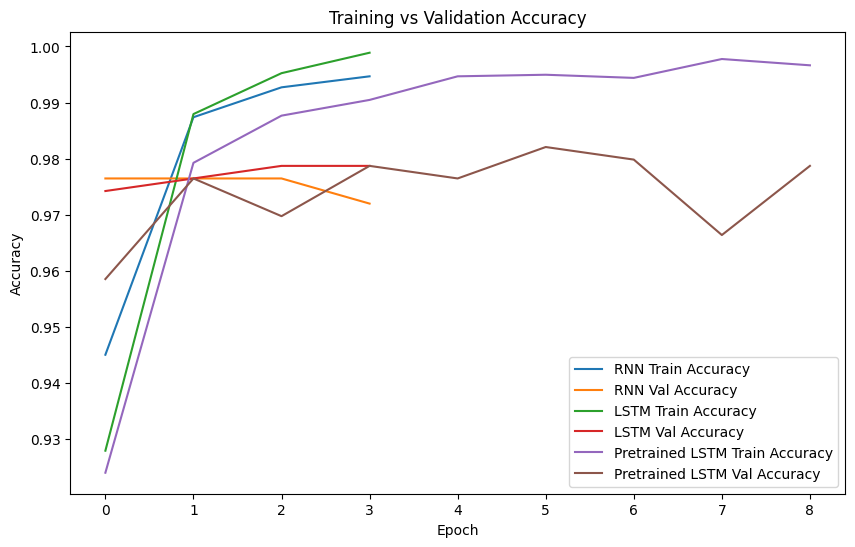

In [196]:
plt.figure(figsize=(10,6))

# RNN
plt.plot(history_rnn.history['accuracy'], label='RNN Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Accuracy')

# LSTM
plt.plot(history_lstm.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')

# Pretrained LSTM
plt.plot(history_pretrained.history['accuracy'], label='Pretrained LSTM Train Accuracy')
plt.plot(history_pretrained.history['val_accuracy'], label='Pretrained LSTM Val Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

### • Evaluate the models using:

– Accuracy.

– Confusion Matrix.

– Classification Report.

In [192]:
# Predict probabilities
rnn_pred_prob = rnn_model.predict(X_test_padded)

# Convert probabilities to class labels
rnn_pred = (rnn_pred_prob > 0.5).astype(int)

# Accuracy
rnn_accuracy = accuracy_score(y_test, rnn_pred)

print("Simple RNN Accuracy:", rnn_accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Simple RNN Accuracy: 0.9775784753363229


In [193]:
lstm_pred_prob = lstm_model.predict(X_test_padded)

lstm_pred = (lstm_pred_prob > 0.5).astype(int)

lstm_accuracy = accuracy_score(y_test, lstm_pred)

print("LSTM Accuracy:", lstm_accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
LSTM Accuracy: 0.9811659192825112


In [194]:
pre_pred_prob = pretrained_lstm_model.predict(X_test_padded)

pre_pred = (pre_pred_prob > 0.5).astype(int)

pre_accuracy = accuracy_score(y_test, pre_pred)

print("Pretrained LSTM Accuracy:", pre_accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Pretrained LSTM Accuracy: 0.9820627802690582


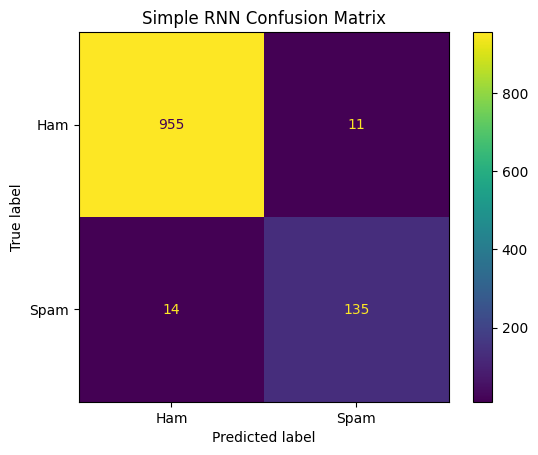

In [197]:
cm_rnn = confusion_matrix(y_test, rnn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rnn,
    display_labels=['Ham', 'Spam']
)

disp.plot()

plt.title("Simple RNN Confusion Matrix")

plt.show()

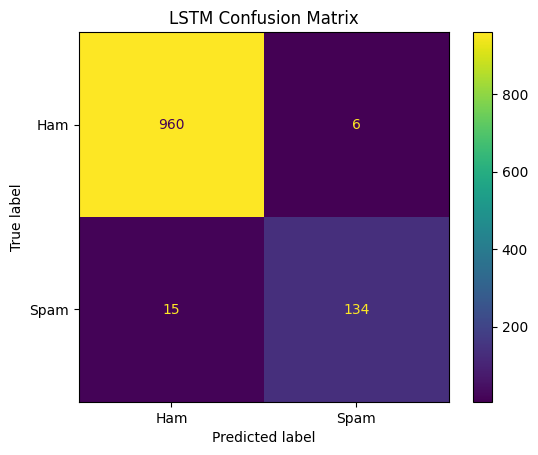

In [198]:
cm_lstm = confusion_matrix(y_test, lstm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=['Ham', 'Spam']
)

disp.plot()

plt.title("LSTM Confusion Matrix")

plt.show()

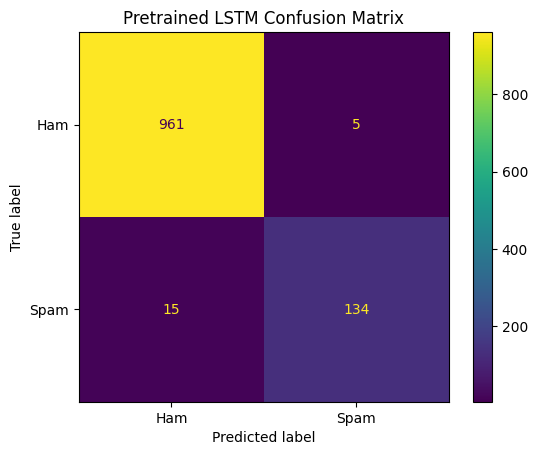

In [199]:
cm_pre = confusion_matrix(y_test, pre_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pre,
    display_labels=['Ham', 'Spam']
)

disp.plot()

plt.title("Pretrained LSTM Confusion Matrix")

plt.show()

In [200]:
print("Simple RNN Report\n")

print(classification_report(
    y_test,
    rnn_pred,
    target_names=['Ham', 'Spam']
))

Simple RNN Report

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.92      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [201]:
print("LSTM Report\n")

print(classification_report(
    y_test,
    lstm_pred,
    target_names=['Ham', 'Spam']
))

LSTM Report

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.96      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [202]:
print("Pretrained LSTM Report\n")

print(classification_report(
    y_test,
    pre_pred,
    target_names=['Ham', 'Spam']
))

Pretrained LSTM Report

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.96      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [203]:
print("\nFinal model Comparision")

print(f"Simple RNN Accuracy: {rnn_accuracy:.4f}")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print(f"Pretrained LSTM Accuracy: {pre_accuracy:.4f}")


Final model Comparision
Simple RNN Accuracy: 0.9776
LSTM Accuracy: 0.9812
Pretrained LSTM Accuracy: 0.9821


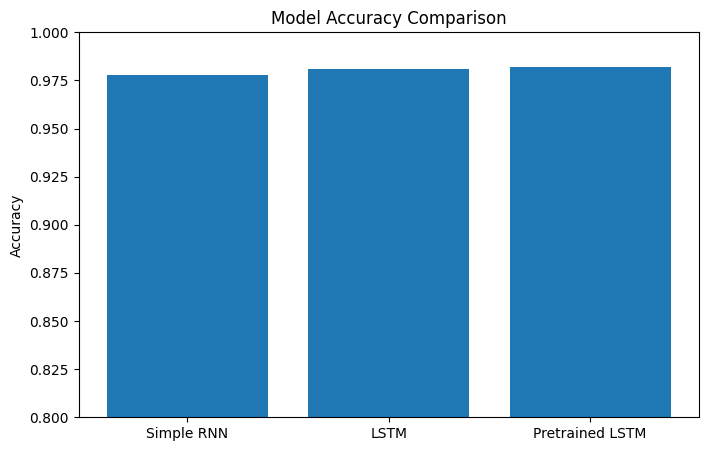

In [204]:
models = ['Simple RNN', 'LSTM', 'Pretrained LSTM']

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    pre_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

plt.ylim(0.8, 1.0)

plt.show()

## 4.5.4 Error Analysis:

### • Analyze misclassified examples:
– Provide 2- 3 incorrect predictions.

– Evaluate Model Complexity vs. Performance.

– Explain Possible reasons for er

In [205]:
#Create dataframe for analysis
error_df = pd.DataFrame({
    'Original_Text': X_test.values,
    'Actual_Label': y_test.values,
    'Predicted_Label': pre_pred.flatten()
})

# Convert labels back to readable form
label_map = {0:'ham', 1:'spam'}

error_df['Actual_Label'] = error_df['Actual_Label'].map(label_map)
error_df['Predicted_Label'] = error_df['Predicted_Label'].map(label_map)

#Find Misclassified Samples
misclassified = error_df[
    error_df['Actual_Label'] != error_df['Predicted_Label']
]

print("Total Misclassified Samples:", len(misclassified))

# Display first 3 incorrect predictions
misclassified.head(3)

Total Misclassified Samples: 20


,Original_Text,Actual_Label,Predicted_Label
9,eh u remember spell name yes v naughty make v wet,ham,spam
23,unsubscribed service get tons sexy babes hunks...,spam,ham
42,v nice sheffield tom air opinions categories b...,ham,spam


In [206]:
for i in range(min(3, len(misclassified))):

    print(f"Misclassified Example {i+1}")

    print("Text:")
    print(misclassified.iloc[i]['Original_Text'])

    print("\nActual Label:")
    print(misclassified.iloc[i]['Actual_Label'])

    print("\nPredicted Label:")
    print(misclassified.iloc[i]['Predicted_Label'])

Misclassified Example 1
Text:
eh u remember spell name yes v naughty make v wet

Actual Label:
ham

Predicted Label:
spam
Misclassified Example 2
Text:
unsubscribed service get tons sexy babes hunks straight phone go subscriptions

Actual Label:
spam

Predicted Label:
ham
Misclassified Example 3
Text:
v nice sheffield tom air opinions categories b use measure ethnicity next census busy transcribe

Actual Label:
ham

Predicted Label:
spam


***Model Complexity VS Performance***

1. Simple RNN
- Lowest model complexity.
- Faster training time.
- Difficulty remembering long-term dependencies.
- Lower accuracy compared to LSTM models.

2. LSTM
- More complicated than Simple RNN.
- Better memory management through gates.
- Enhanced results on textual sequences.
- Increased computational expense.

3. Pre-trained LSTM (GloVe)
- Greatest level of complexity.
- Utilizes semantically enriched information due to pre-trained vectors.
- Greatest degree of generalization and context recognition.
- Greater memory requirements and processing costs.

**Possible Reasons for errors**

1. Ambiguous Language
2. Short Text Length
3. Vocabulary Limitation
4. Loss of information during cleaning
5. Class Imbalance



### • Suggest potential improvements.

**Suggested potential improvemnets are :**

1. Increase training data  
2. Better text cleaning
3. Handle class imbalance
4. Hyperparameter tuning
5. Fine-tune pretained embeddings

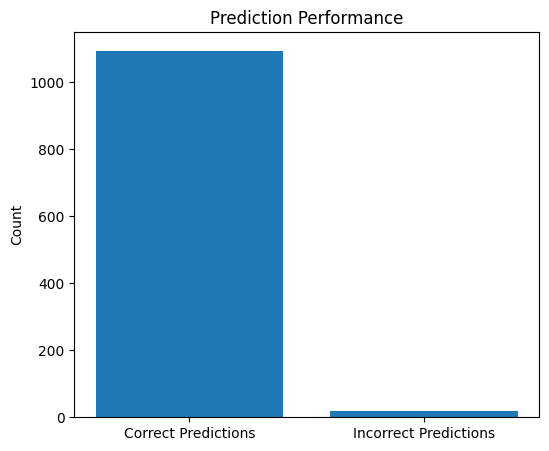

In [207]:
correct = len(error_df) - len(misclassified)
incorrect = len(misclassified)

labels = ['Correct Predictions', 'Incorrect Predictions']
values = [correct, incorrect]

plt.figure(figsize=(6,5))

plt.bar(labels, values)

plt.ylabel('Count')
plt.title('Prediction Performance')

plt.show()

## 4.5.5 GUI for Real Time Prediction:

In [208]:
def predict_spam(text, model_choice):
    # Step 1: Clean text
    cleaned_text = text_cleaning_pipeline(text)

    # Step 2: Tokenize and pad
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # Step 3: Select model based on dropdown
    model_map = {
        "Simple RNN": rnn_model,
        "LSTM": lstm_model,
        "Pretrained LSTM (GloVe)": pretrained_lstm_model,
    }
    selected_model = model_map[model_choice]

    # Step 4: Predict
    prediction = selected_model.predict(padded)[0][0]
    label = "SPAM" if prediction > 0.5 else "HAM"

    confidence = prediction if prediction > 0.5 else 1 - prediction

    return (
        f"Prediction : {label}\n"
        f"Model used : {model_choice}\n"
        f"Spam prob  : {prediction:.4f}\n"
        f"Confidence : {confidence * 100:.1f}%"
    )


# Build Gradio interface with model selector
interface = gr.Interface(
    fn=predict_spam,
    inputs=[
        gr.Textbox(
            lines=4,
            placeholder="Enter a message here...",
            label="Message"
        ),
        gr.Dropdown(
            choices=[
                "Simple RNN",
                "LSTM",
                "Pretrained LSTM (GloVe)",
            ],
            value="Pretrained LSTM (GloVe)",
            label="Select Model"
        ),
    ],
    outputs=gr.Textbox(label="Result"),
    title="Spam vs Ham SMS Classifier",
    description="Enter a message and choose a model to classify it.",
    examples=[
        ["Congratulations! You've won a FREE prize. Call now!", "Pretrained LSTM (GloVe)"],
        ["Hey, are we still meeting at 5pm today?", "LSTM"],
        ["URGENT: Your account has been compromised. Click here.", "Simple RNN"],
    ],
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8b2071a30d6cfa361.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
